In [1]:
import sys
from pathlib import Path

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *
# ignore folder path printouts. These are only relevant for complete installations of https://github.com/proxipal-pcr

OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-05-19 13:20:38
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\ELISA Calibrator Selection
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\

In [2]:
# Load and Inspect
elisa_data = pd.read_csv('ELISA Calibrator Performance (Uman kit) data 2.csv')
elisa_data['log10(pg/ml)'] = np.log10(elisa_data['pg/ml'])
elisa_data.head(7)

C:\Users\smith.j\Miniforge3\envs\ProxiPaL2\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,pg/ml,abs,calibrator,test,plate,log10(pg/ml)
0,10000,3.148,IBL-Uman,1,1,4.00000
1,5000,2.745,IBL-Uman,1,1,3.69897
2,2500,1.905,IBL-Uman,1,1,3.39794
3,1000,0.936,IBL-Uman,1,1,3.00000
4,500,0.516,IBL-Uman,1,1,2.69897
5,100,0.114,IBL-Uman,1,1,2.00000
6,0,0.013,IBL-Uman,1,1,-inf


### Calibrator Normalisation Strategy
Standard curves for the Uman-type NfL ELISA were generated using multiple calibrator preparations across three assay plates (plates 1–2: commercial capture plates; plate 3: in-house capture plate). Because absolute absorbance values vary between plates due to inter-run variability, direct comparison of calibrator performance across plates requires normalisation to a common reference.  
  
IBL-Uman was the only calibrator tested on all three plates and was therefore used as the normalisation anchor. For each plate, a four-parameter logistic (4PL) curve was fitted to the IBL-Uman standard curve data using log10-transformed concentrations as the independent variable. The fitted curves were used to interpolate the expected absorbance at each concentration point present in the dataset.  
  
Plate 1 was designated the reference plate (conversion factor = 1). For plates 2 and 3, a concentration-specific conversion factor was calculated as the ratio of the plate 1 interpolated absorbance to the plate N interpolated absorbance at each concentration. These conversion factors were then applied to the raw absorbance values of all calibrators run on the corresponding plate:  
  
`abs_norm = abs × conversion_factor`  
  
This normalises all absorbance values to a common plate 1 reference frame, enabling direct comparison of standard curve shape and signal magnitude across calibrators regardless of which plate they were run on.  
  
Prior to plotting, the following exclusions were applied to the normalised dataset: duplicate IBL-Uman data from plates 2 and 3 (retained only from plate 1 as the reference); concentrations above 5000 pg/ml; and Progen calibrator data from plate 2 (plate 3 data retained).


In [3]:
# Extract IBL-Uman data, test 1
IBL_1 = elisa_data[(elisa_data['calibrator'] == 'IBL-Uman') & (elisa_data['test'] == 1)]
IBL_1

,pg/ml,abs,calibrator,test,plate,log10(pg/ml)
0,10000,3.148,IBL-Uman,1,1,4.00000
1,5000,2.745,IBL-Uman,1,1,3.69897
2,2500,1.905,IBL-Uman,1,1,3.39794
3,1000,0.936,IBL-Uman,1,1,3.00000
4,500,0.516,IBL-Uman,1,1,2.69897
5,100,0.114,IBL-Uman,1,1,2.00000
6,0,0.013,IBL-Uman,1,1,-inf


### To fit a 4PL use a custom function from ProxiPal.py  
The function predicts the 4PL parameters for you.

C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\ProxiPal.py:4445: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fit_func, concentration, response,


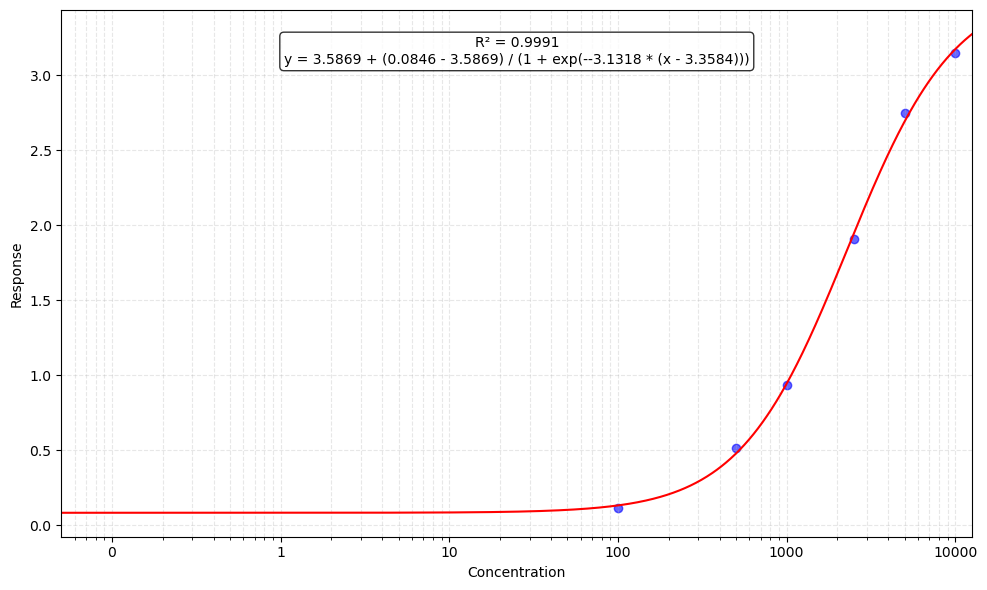

In [4]:
# Plate 1
# Conduct 4PL, remove pg/ml == 0 row
IBL_1_conc_log = IBL_1['log10(pg/ml)'][:-1]
IBL_1_response_log = IBL_1['abs'][:-1]
IBL_1_metrics_df, IBL_1_equation = robust_4pl_fit(IBL_1_conc_log, IBL_1_response_log, transform_x="log10(x)", plot = True)

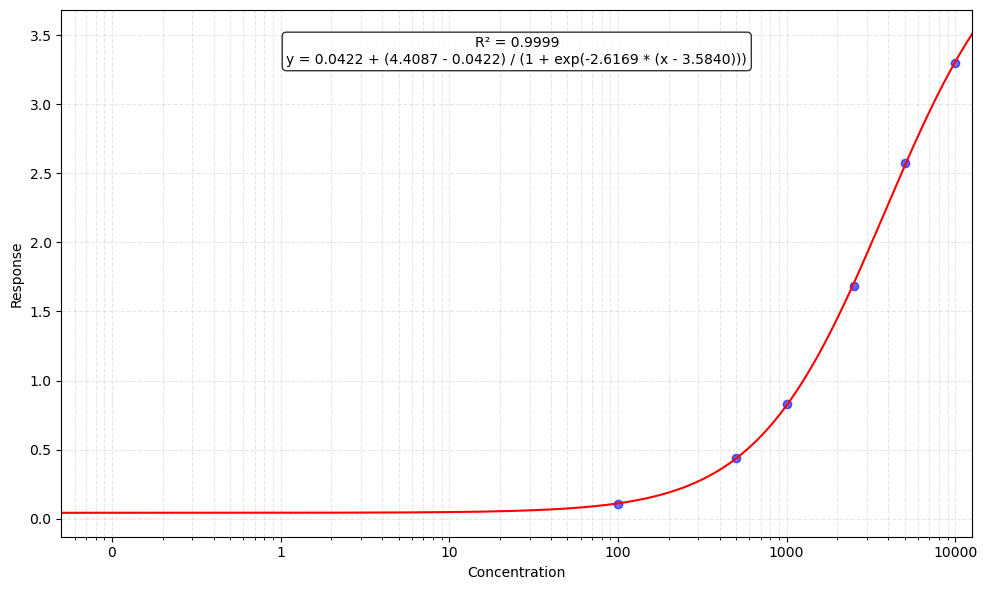

In [5]:
# Extract IBL-Uman data, test 2
IBL_2 = elisa_data[(elisa_data['calibrator'] == 'IBL-Uman') & (elisa_data['test'] == 2)]

# Repeat 4PL, remove pg/ml == 0 row
IBL_2_conc_log = IBL_2['log10(pg/ml)'][:-1]
IBL_2_response_log = IBL_2['abs'][:-1]
IBL_2_metrics_df, IBL_2_equation = robust_4pl_fit(IBL_2_conc_log, IBL_2_response_log, transform_x="log10(x)", plot = True)

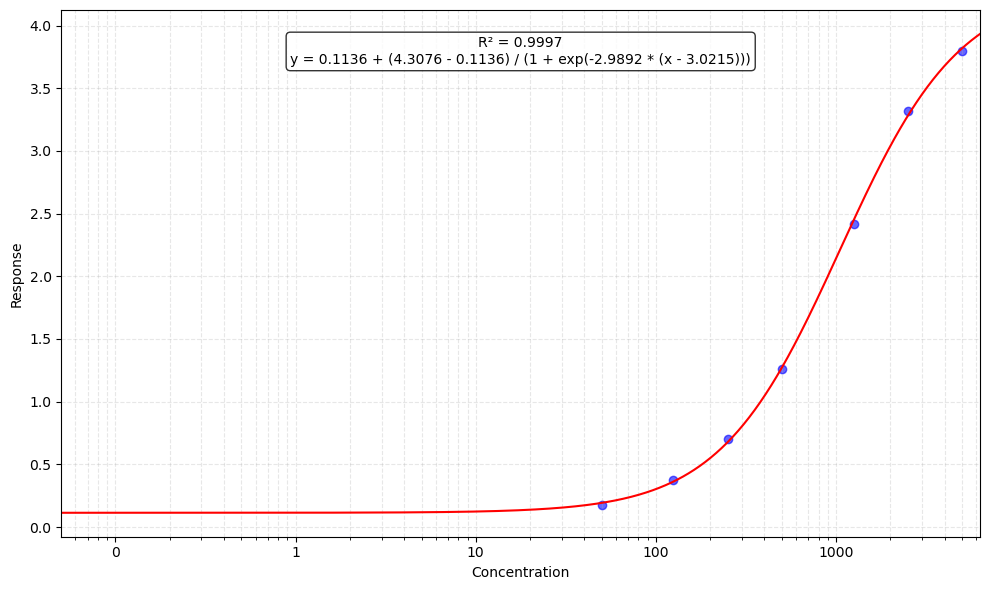

In [6]:
# Extract IBL-Uman data, test 3
IBL_3 = elisa_data[(elisa_data['calibrator'] == 'IBL-Uman') & (elisa_data['test'] == 3)]

# Repeat 4PL, remove pg/ml == 0 row
IBL_3_conc_log = IBL_3['log10(pg/ml)'][:-1]
IBL_3_response_log = IBL_3['abs'][:-1]
IBL_3_metrics_df, IBL_3_equation = robust_4pl_fit(IBL_3_conc_log, IBL_3_response_log, transform_x="log10(x)", plot = True)

In [7]:
# save metrics in a dictionary
PL_metrics = {'plate 1': IBL_1_metrics_df, 'plate 2': IBL_2_metrics_df, 'plate 3': IBL_3_metrics_df}
PL_metrics['plate 1']

,Metric,Value
0,Fitting Method,trf
1,Transform,log10(x)
2,Composite Score,0.757155
3,A (upper asymptote),3.586935
4,B (slope),-3.131757
5,C (EC50),3.358416
6,D (lower asymptote),0.084621
7,R²,0.99908
8,Adjusted R²,0.995402
9,RMSE,0.034165


### Calculate conversion factors for each plate 
Extract all IBL-Uman data (excluding the blank at 0 pg/ml) to get the full list of concentrations at which to interpolate absorbance values from each plate's 4PL curve.  

In [8]:
## Interpolation function
# Define a function to predict absorbance from a given concentration using 4PL parameters.
# Concentration is log10-transformed internally before evaluation. 
# Returns NaN for zero or negative concentrations, which are undefined on a log scale.

def predict_4pl_abs_logx(c, A, B, C, D):
    """
    Predict y from log10 concentration using:
    y = A + (D - A) / (1 + exp(-B * (log10(c) - C)))
    """
    try:
        if c <= 0:
            return np.nan
        x = np.log10(c)
        return A + (D - A) / (1 + np.exp(-B * (x - C)))
    except Exception:
        return np.nan


In [9]:
# Extract the full IBL-Uman set, minus the pg/ml == 0
IBL_all = elisa_data[(elisa_data['calibrator'] == 'IBL-Uman') & (elisa_data['pg/ml'] != 0)]
IBL_all

,pg/ml,abs,calibrator,test,plate,log10(pg/ml)
0,10000,3.148,IBL-Uman,1,1,4.00000
1,5000,2.745,IBL-Uman,1,1,3.69897
2,2500,1.905,IBL-Uman,1,1,3.39794
3,1000,0.936,IBL-Uman,1,1,3.00000
4,500,0.516,IBL-Uman,1,1,2.69897
5,100,0.114,IBL-Uman,1,1,2.00000
28,10000,3.302,IBL-Uman,2,2,4.00000
29,5000,2.572,IBL-Uman,2,2,3.69897
30,2500,1.681,IBL-Uman,2,2,3.39794
31,1000,0.828,IBL-Uman,2,2,3.00000


In [10]:
# Create concentration list for all tested concentraitons
conc_list = IBL_all['pg/ml'].unique().tolist()
conc_list.sort(reverse=True)

# Calculate interpolated absorbance values
absorbance_dict = {}
for key, df in PL_metrics.items():
    A = df.loc[df['Metric'] == 'A (upper asymptote)', 'Value'].values[0]
    B = df.loc[df['Metric'] == 'B (slope)', 'Value'].values[0]
    C = df.loc[df['Metric'] == 'C (EC50)', 'Value'].values[0]
    D = df.loc[df['Metric'] == 'D (lower asymptote)', 'Value'].values[0]
    print(key, A, B, C, D)
    
    print('predicted ABS near LOD (30): ', predict_4pl_abs_logx(30, A = A, B = B, C = C, D = D))
    
    absorbance_list = []
    for conc in conc_list:
        absorbance = predict_4pl_abs_logx(conc, A = A, B = B, C = C, D = D)
        absorbance_list.append(absorbance)
    
    absorbance_dict[key] = absorbance_list

plate 1 3.5869350723174795 -3.131757405146062 3.3584160379355055 0.08462112324128934
predicted ABS near LOD (30):  0.094268267908308
plate 2 0.042153538138008616 2.616940891244656 3.584037876945501 4.40868282530543
predicted ABS near LOD (30):  0.059685477775289764
plate 3 0.11359076395793809 2.9891839300906846 3.0215415711779174 4.307643485920712
predicted ABS near LOD (30):  0.15465050733745528


In [11]:
# Create dataframe
IBL_Uman_4PL_df = pd.DataFrame(data=absorbance_dict, index=conc_list)

# Calculate conversion factors for each concentration point
IBL_Uman_4PL_df['plate 1 cf'] = 1
IBL_Uman_4PL_df['plate 2 cf'] = IBL_Uman_4PL_df['plate 1']/IBL_Uman_4PL_df['plate 2']
IBL_Uman_4PL_df['plate 3 cf'] = IBL_Uman_4PL_df['plate 1']/IBL_Uman_4PL_df['plate 3']

IBL_Uman_4PL_df

,plate 1,plate 2,plate 3,plate 1 cf,plate 2 cf,plate 3 cf
10000,3.172851,3.308790,4.093992,1,0.958916,0.775002
5000,2.690122,2.551296,3.818586,1,1.054414,0.704481
2500,1.944019,1.704050,3.279840,1,1.140823,0.592717
1250,1.156265,0.995975,2.445843,1,1.160938,0.472747
1000,0.944625,0.820396,2.143125,1,1.151426,0.440770
500,0.478712,0.434235,1.271287,1,1.102425,0.376557
250,0.249464,0.229673,0.676561,1,1.086170,0.368723
125,0.150736,0.129492,0.362326,1,1.164053,0.416022
100,0.133671,0.110233,0.302589,1,1.212625,0.441759
50,0.103894,0.073385,0.192556,1,1.415729,0.539551


## Apply conversion factors

For each measurement in the dataset, retrieve the appropriate conversion factor from 
`IBL_Uman_4PL_df` based on the plate number and concentration of that row. 
Normalised absorbance is then calculated as:

`abs_norm = abs × abs_cf`

This places all measurements on a common plate 1 reference frame.

In [12]:
def get_abs_cf(row):
    pg = row['pg/ml']
    test_num = int(row['plate'])  # e.g., 1, 2, 3
    column_name = f'plate {test_num} cf'
    
    if pg in IBL_Uman_4PL_df.index and column_name in IBL_Uman_4PL_df.columns:
        return IBL_Uman_4PL_df.loc[pg, column_name]
    else:
        return np.nan

In [13]:
# exclude pg/ml == 0 from the conversion results- they can't be mapped onto a log10 conc plot anyway. 
elisa_data_sub0 = elisa_data[elisa_data['pg/ml'] != 0]
elisa_data_sub0

,pg/ml,abs,calibrator,test,plate,log10(pg/ml)
0,10000,3.148,IBL-Uman,1,1,4.00000
1,5000,2.745,IBL-Uman,1,1,3.69897
2,2500,1.905,IBL-Uman,1,1,3.39794
3,1000,0.936,IBL-Uman,1,1,3.00000
4,500,0.516,IBL-Uman,1,1,2.69897
...,...,...,...,...,...,...
91,1250,0.242,Abnova,1,3,3.09691
92,500,0.113,Abnova,1,3,2.69897
93,250,0.073,Abnova,1,3,2.39794
94,125,0.052,Abnova,1,3,2.09691


In [14]:
elisa_data_sub0 = elisa_data_sub0.copy()
elisa_data_sub0['abs_cf'] = elisa_data_sub0.apply(get_abs_cf, axis=1)
elisa_data_sub0['abs_norm'] = elisa_data_sub0['abs'] * elisa_data_sub0['abs_cf']
elisa_data_sub0

,pg/ml,abs,calibrator,test,plate,log10(pg/ml),abs_cf,abs_norm
0,10000,3.148,IBL-Uman,1,1,4.00000,1.000000,3.148000
1,5000,2.745,IBL-Uman,1,1,3.69897,1.000000,2.745000
2,2500,1.905,IBL-Uman,1,1,3.39794,1.000000,1.905000
3,1000,0.936,IBL-Uman,1,1,3.00000,1.000000,0.936000
4,500,0.516,IBL-Uman,1,1,2.69897,1.000000,0.516000
...,...,...,...,...,...,...,...,...
91,1250,0.242,Abnova,1,3,3.09691,0.472747,0.114405
92,500,0.113,Abnova,1,3,2.69897,0.376557,0.042551
93,250,0.073,Abnova,1,3,2.39794,0.368723,0.026917
94,125,0.052,Abnova,1,3,2.09691,0.416022,0.021633


### Clean up the plotting data

In [15]:
# We'll drop the IBL-Uman values from plates 2 and 3
elisa_data_sub0_f = elisa_data_sub0[
    ~((elisa_data_sub0['calibrator'] == 'IBL-Uman') & 
      (elisa_data_sub0['plate'].isin([2, 3])))]

# We'll also drop where pg/ml >5000
elisa_data_sub0_ff =elisa_data_sub0_f[~(elisa_data_sub0['pg/ml'] >5000)]

# We'll also drop progen from plate 2. we'll keep the results from plate 3.
elisa_data_sub0_fff = elisa_data_sub0_ff[
    ~((elisa_data_sub0_ff['calibrator'] == 'Progen') & (elisa_data_sub0_ff['plate'] == 2))]

# Create log10(pg/ml)
elisa_data_sub0_fff = elisa_data_sub0_fff.copy()
elisa_data_sub0_fff['log10(pg/ml)'] = np.log10(elisa_data_sub0_fff['pg/ml'])


# Create renamed dataframe
elisa_data_sub0_fff_rename = elisa_data_sub0_fff.copy()

elisa_data_sub0_fff_rename['calibrator'] = (
    elisa_data_sub0_fff_rename['calibrator']
    .replace({
        'IBL-Uman': 'Uman',
        'PK': 'PerkinElmer',
        'RnD': 'R&D'
    })
)

# export
elisa_data_sub0_fff_rename.to_csv('output.csv')

# inspect
elisa_data_sub0_fff_rename

C:\Users\smith.j\AppData\Local\Temp\ipykernel_35392\846115068.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  elisa_data_sub0_ff =elisa_data_sub0_f[~(elisa_data_sub0['pg/ml'] >5000)]


,pg/ml,abs,calibrator,test,plate,log10(pg/ml),abs_cf,abs_norm
1,5000,2.745,Uman,1,1,3.69897,1.000000,2.745000
2,2500,1.905,Uman,1,1,3.39794,1.000000,1.905000
3,1000,0.936,Uman,1,1,3.00000,1.000000,0.936000
4,500,0.516,Uman,1,1,2.69897,1.000000,0.516000
5,100,0.114,Uman,1,1,2.00000,1.000000,0.114000
8,5000,0.342,R&D,1,1,3.69897,1.000000,0.342000
9,2500,0.169,R&D,1,1,3.39794,1.000000,0.169000
10,1000,0.078,R&D,1,1,3.00000,1.000000,0.078000
11,500,0.045,R&D,1,1,2.69897,1.000000,0.045000
12,100,0.020,R&D,1,1,2.00000,1.000000,0.020000


### Plot normalised standard curves

For each calibrator in `elisa_data_sub0_fff`, fit a 4PL curve to the normalised 
absorbance values (`abs_norm`) using `robust_4pl_fit`. The fitted parameters 
(A, B, C, D) are extracted from the returned metrics dataframe and used to 
reconstruct a smooth curve for plotting. Raw data points are overlaid. 
X-axis is log-scaled concentration (pg/ml), y-axis is normalised absorbance. 
Calibrators with fewer than 4 data points are skipped as insufficient for 4PL fitting.

In [16]:
# Okabe-Ito palette
okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

# Explicit calibrator colour assignments
calibrator_colours = {
    'Uman':     okabe_ito['black'],
    'Progen':   okabe_ito['vermillion'],
    'R&D':      okabe_ito['reddish purple'],
    'PerkinElmer':       okabe_ito['bluish green'],
    'Origene':  okabe_ito['orange'],
    'Abcam':    okabe_ito['blue'],
    'MyBio':    okabe_ito['sky blue'],
    'Ella':     okabe_ito['yellow'],
    'Encor':    okabe_ito['orange'],    # shares colour with Origene
    'Abnova':   okabe_ito['sky blue'],  # shares colour with RnD
}

def get_style(calibrator):
    colour = calibrator_colours[calibrator]
    sharing = [k for k, v in calibrator_colours.items() if v == colour]
    if len(sharing) > 1 and sharing.index(calibrator) > 0:
        return colour, '--'
    return colour, '-'

def xlog10_4PL(x, A, B, C, D):
    return A + (D - A) / (1 + np.exp(-B * (x - C)))

In [17]:
plot_data = pd.read_csv('output.csv')

C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\ProxiPal.py:4445: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fit_func, concentration, response,
C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\ProxiPal.py:4365: RuntimeWarning: overflow encountered in exp
  return A + (D - A) / (1 + np.exp(-B * (x - C)))


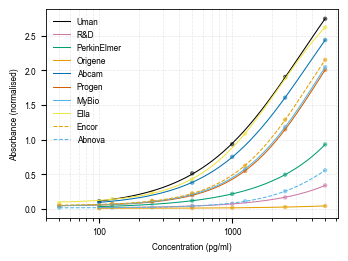

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

# Nat Comms figure formatting
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
plt.rcParams['font.size'] = 6
plt.rcParams['axes.titlesize'] = 6
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['scatter.edgecolors'] = 'none'
plt.rcParams['axes.linewidth'] = 0.6


fig, ax = plt.subplots(figsize=(88/25.4, 66/25.4))

for calibrator in plot_data['calibrator'].unique():
    df = plot_data[plot_data['calibrator'] == calibrator]
    x = df['log10(pg/ml)'].values
    y = df['abs_norm'].values

    if len(x) < 4:
        continue

    colour, linestyle = get_style(calibrator)

    try:
        metrics_df, equation = robust_4pl_fit(x, y, transform_x="log10(x)", plot=False)

        popt = [
            metrics_df.loc[metrics_df['Metric'] == 'A (upper asymptote)', 'Value'].values[0],
            metrics_df.loc[metrics_df['Metric'] == 'B (slope)', 'Value'].values[0],
            metrics_df.loc[metrics_df['Metric'] == 'C (EC50)', 'Value'].values[0],
            metrics_df.loc[metrics_df['Metric'] == 'D (lower asymptote)', 'Value'].values[0],
        ]

        ax.scatter(10**x, y, s=10, alpha=0.6, facecolor=colour, edgecolors='none')

        x_smooth_log = np.linspace(min(x), max(x), 300)
        x_smooth = 10**x_smooth_log
        y_smooth = xlog10_4PL(x_smooth_log, *popt)
        ax.plot(x_smooth, y_smooth, label=calibrator, color=colour,
                linewidth=0.75, linestyle=linestyle)

    except Exception as e:
        print(f"Fit failed for {calibrator}: {e}")

ax.set_xscale('log')
ax.set_xlabel('Concentration (pg/ml)')
ax.set_ylabel('Absorbance (normalised)')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("ELISA Calibrator Lin-Log.svg", dpi=300, bbox_inches='tight')
plt.show()

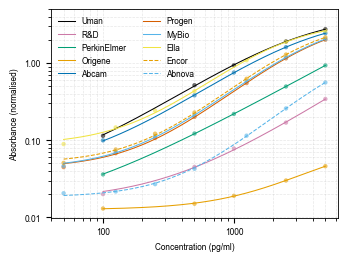

In [19]:
# Nat Comms figure formatting
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
plt.rcParams['font.size'] = 6
plt.rcParams['axes.titlesize'] = 6
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['scatter.edgecolors'] = 'none'
plt.rcParams['axes.linewidth'] = 0.6


fig, ax = plt.subplots(figsize=(88/25.4, 66/25.4))

for calibrator in plot_data['calibrator'].unique():
    df = plot_data[plot_data['calibrator'] == calibrator]
    x = df['log10(pg/ml)'].values
    y = df['abs_norm'].values

    if len(x) < 4 or np.any(y <= 0):
        continue

    colour, linestyle = get_style(calibrator)

    try:
        metrics_df, equation = robust_4pl_fit(x, y, transform_x="log10(x)", plot=False)

        popt = [
            metrics_df.loc[metrics_df['Metric'] == 'A (upper asymptote)', 'Value'].values[0],
            metrics_df.loc[metrics_df['Metric'] == 'B (slope)', 'Value'].values[0],
            metrics_df.loc[metrics_df['Metric'] == 'C (EC50)', 'Value'].values[0],
            metrics_df.loc[metrics_df['Metric'] == 'D (lower asymptote)', 'Value'].values[0],
        ]

        ax.scatter(10**x, y, s=10, alpha=0.6, facecolor=colour, edgecolors='none')

        x_smooth_log = np.linspace(min(x), max(x), 300)
        x_smooth = 10**x_smooth_log
        y_smooth = xlog10_4PL(x_smooth_log, *popt)
        ax.plot(x_smooth, y_smooth, label=calibrator, color=colour,
                linewidth=0.75, linestyle=linestyle)

    except Exception as e:
        print(f"Fit failed for {calibrator}: {e}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Concentration (pg/ml)')
ax.set_ylabel('Absorbance (normalised)')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.legend(frameon=False, ncols=2)

ax.set_ylim(bottom=None, top=5)
plt.tight_layout()
plt.savefig("ELISA Calibrator Log-Log.svg", dpi=300, bbox_inches='tight')
plt.show()